# SUR 2025/2026 — Report figures (v2)

Fresh visual style for `docs/draft.md`. Figs 1-7 saved to `docs/figures/`.

In [1]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

from __future__ import annotations
import pickle, pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy.special import ndtri
import scipy.stats as stats
from sklearn.metrics import roc_curve

PROJ  = pathlib.Path("..")
OUT   = PROJ / "docs" / "figures"
CACHE = PROJ / "cache"
OUT.mkdir(parents=True, exist_ok=True)

In [2]:
P = dict(
    audio    = "#3A7EC5",
    audio_lt = "#AECDE8",
    image    = "#C84B2F",
    image_lt = "#EDB49E",
    fusion   = "#1F9E72",
    fusion_lt= "#8FD9BB",
    mfcc     = "#7C54B0",
    mfcc_lt  = "#C4AFDC",
    amber    = "#E8A820",
    ink      = "#1A2035",
    sub      = "#5A6B85",
    grid     = "#EDF1F8",
    bg       = "#FFFFFF",
)

STREAM    = dict(audio=P["audio"],    image=P["image"],    fusion=P["fusion"])
STREAM_LT = dict(audio=P["audio_lt"], image=P["image_lt"], fusion=P["fusion_lt"])

plt.rcParams.update({
    "font.size":          11.5,
    "axes.facecolor":     P["bg"],
    "figure.facecolor":   P["bg"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "xtick.color":        P["sub"],
    "ytick.color":        P["sub"],
    "axes.labelcolor":    P["sub"],
    "text.color":         P["ink"],
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  P["bg"],
    "legend.frameon":     False,
    "legend.fontsize":    11,
})
sns.set_style("white")

def ygrid(ax):
    ax.yaxis.grid(True, color=P["grid"], linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)

def xygrid(ax):
    ax.xaxis.grid(True, color=P["grid"], linewidth=0.9, zorder=0)
    ax.yaxis.grid(True, color=P["grid"], linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)

def save(fig, name):
    p = OUT / name
    fig.savefig(p.with_suffix(".pdf"))
    fig.savefig(p.with_suffix(".png"), dpi=300)
    print(f"  saved {name}")

## Figure 1 — GMM covariance ablation (E037)
Horizontal lollipop. Winner highlighted in saturated blue.

  saved fig1_covariance_ablation


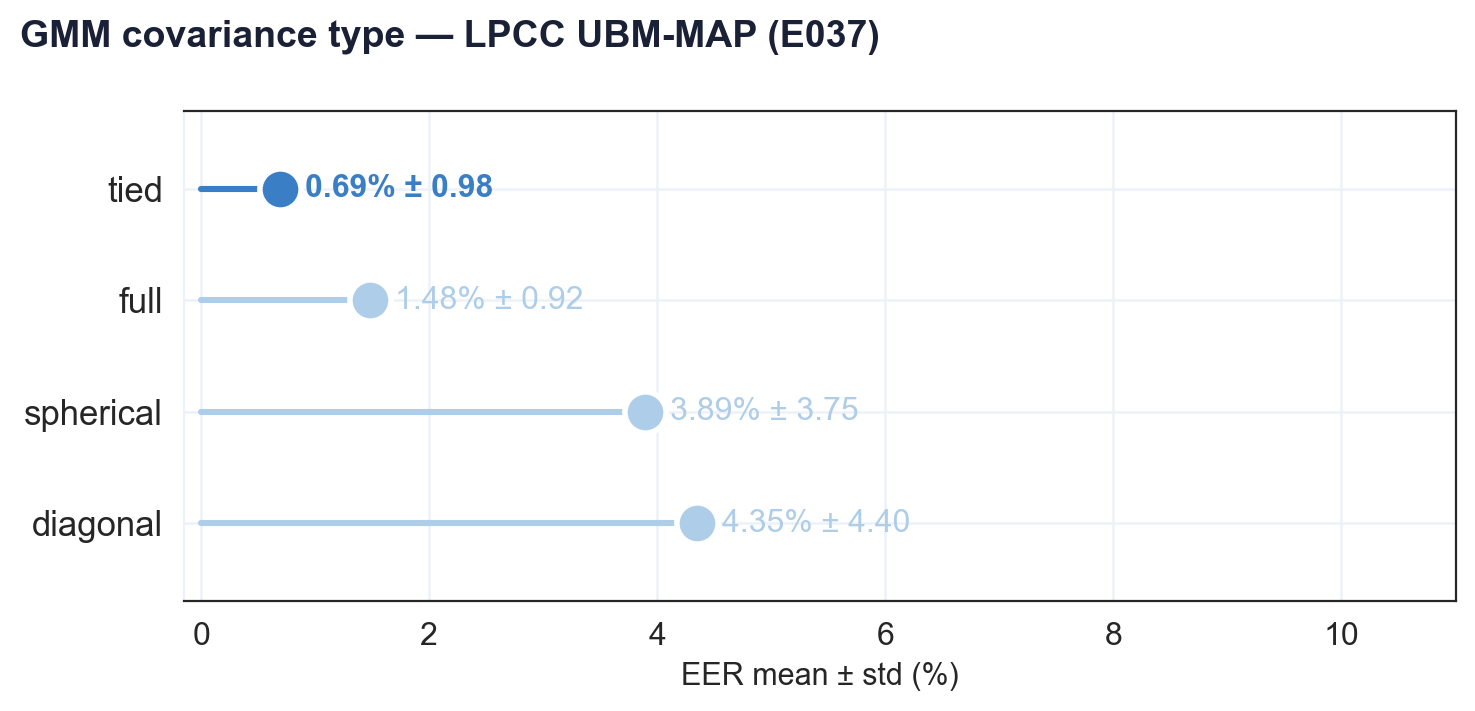

In [3]:
cov = pd.DataFrame({
    "label": ["spherical", "diagonal", "full", "tied"],
    "eer":   [3.89, 4.35, 1.48, 0.69],
    "std":   [3.75, 4.40, 0.92, 0.98],
    "win":   [False, False, False, True],
}).sort_values("eer", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
y = np.arange(len(cov))

for i, row in cov.iterrows():
    eer = float(row["eer"]); std = float(row["std"]); win = bool(row["win"])
    c  = P["audio"] if win else P["audio_lt"]
    fw = "bold" if win else "normal"
    ax.plot([0, eer], [y[i], y[i]], color=c, lw=2.2,
            solid_capstyle="round", zorder=2)
    ax.scatter([eer], [y[i]], s=220, color=c, zorder=4,
               edgecolors="white", linewidths=2)
    ax.text(eer + 0.22, y[i], f"{eer:.2f}% ± {std:.2f}",
            va="center", ha="left", color=c, fontsize=11.5, fontweight=fw)

ax.set_yticks(y)
ax.set_yticklabels(cov["label"], fontsize=12.5)
ax.set_xlim(-0.15, 11.0)
ax.set_ylim(-0.7, len(cov) - 0.3)
ax.set_xlabel("EER mean ± std (%)", fontsize=11)
ax.spines["left"].set_color(P["grid"])
ax.tick_params(left=False)
xygrid(ax)

fig.suptitle("GMM covariance type — LPCC UBM-MAP (E037)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig1_covariance_ablation")
plt.show()

## Figure 2 — Adversarial rotation robustness (E033)

  saved fig2_adv_rot_robustness


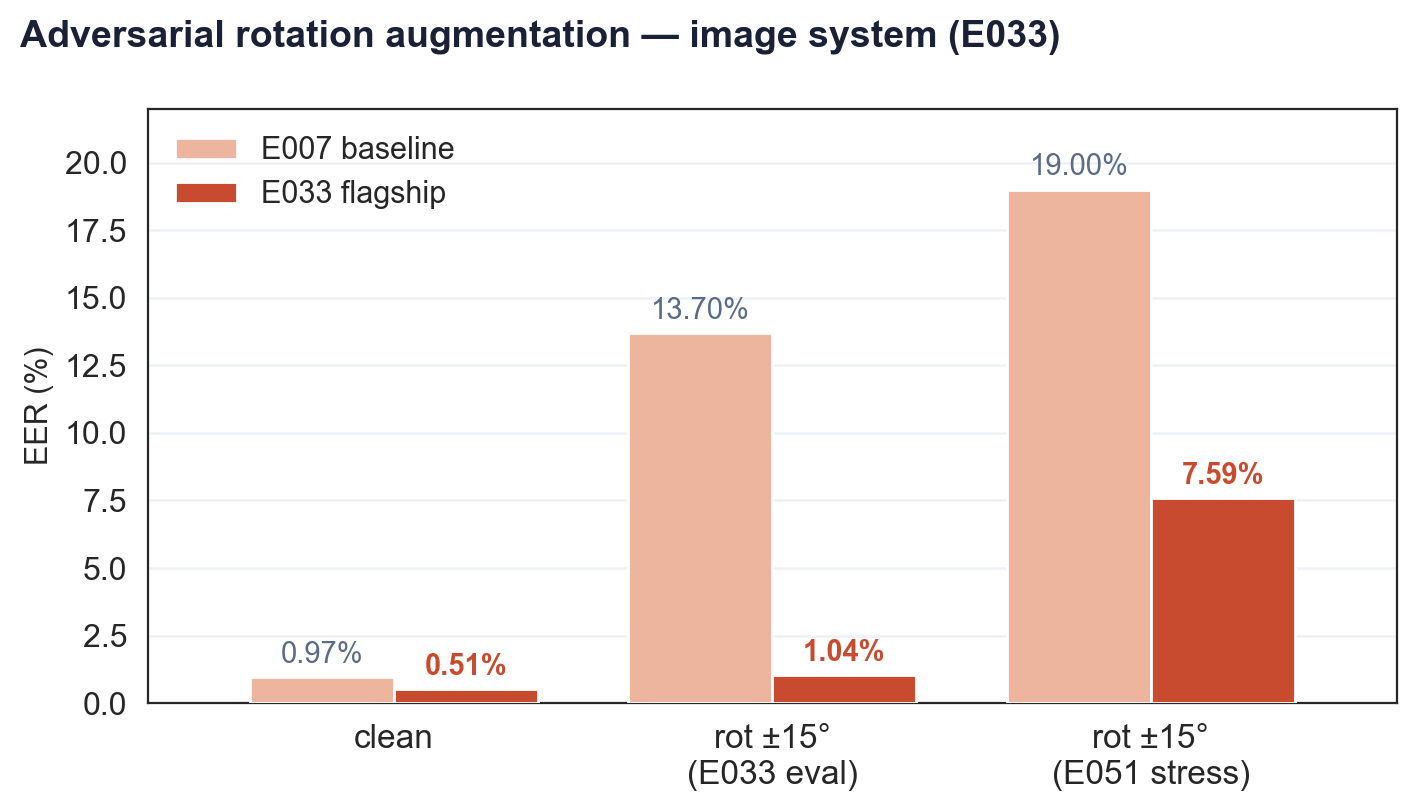

In [4]:
conds    = ["clean", "rot ±15°\n(E033 eval)", "rot ±15°\n(E051 stress)"]
base     = np.array([0.97, 13.70, 19.00])
flagship = np.array([0.51,  1.04,  7.59])

x = np.arange(len(conds)); w = 0.38
fig, ax = plt.subplots(figsize=(7.2, 4.1))

ax.bar(x - w/2, base,     w, color=P["image_lt"], zorder=3, label="E007 baseline")
ax.bar(x + w/2, flagship, w, color=P["image"],    zorder=3, label="E033 flagship")

ymax = 22
ax.set_ylim(0, ymax)
ygrid(ax)
ax.set_xticks(x); ax.set_xticklabels(conds, fontsize=12)
ax.set_ylabel("EER (%)", fontsize=11)
ax.set_xlim(-0.65, len(conds) - 0.35)

pad = ymax * 0.014
for xi, (b, f) in enumerate(zip(base, flagship)):
    ax.text(xi - w/2, b + pad, f"{b:.2f}%", ha="center", va="bottom",
            fontsize=10.5, color=P["sub"])
    ax.text(xi + w/2, f + pad, f"{f:.2f}%", ha="center", va="bottom",
            fontsize=10.5, color=P["image"], fontweight="bold")

ax.legend(loc="upper left", fontsize=11)
fig.suptitle("Adversarial rotation augmentation — image system (E033)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig2_adv_rot_robustness")
plt.show()

## Figure 3 — Codec-bandwidth robustness (E052)
Slope/connected-dot chart.

  saved fig3_codec_robustness


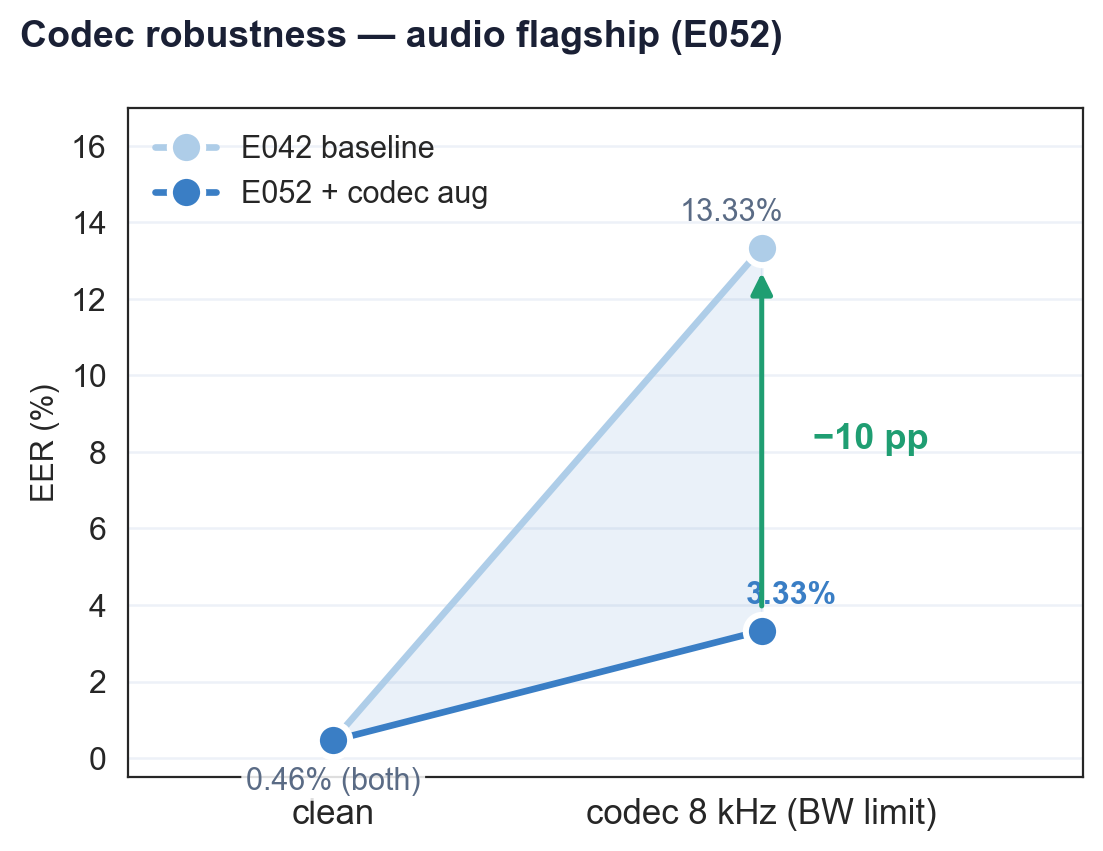

In [5]:
E042 = [0.46, 13.33]
E052 = [0.46,  3.33]
xs   = [0, 1]

fig, ax = plt.subplots(figsize=(5.6, 4.3))

# Improvement shading
ax.fill_between(xs, E042, E052, color=P["audio"], alpha=0.10, zorder=1)

# Lines
ax.plot(xs, E042, "o-", color=P["audio_lt"], lw=2.4, ms=12,
        markeredgecolor="white", markeredgewidth=2.2, zorder=3,
        label="E042 baseline")
ax.plot(xs, E052, "o-", color=P["audio"],    lw=2.4, ms=12,
        markeredgecolor="white", markeredgewidth=2.2, zorder=3,
        label="E052 + codec aug")

# Value labels (left side slightly left, right side slightly right)
for xi, (a, b) in enumerate(zip(E042, E052)):
    if abs(a - b) < 0.01:
        ax.text(xi, a - 0.7, f"{a:.2f}% (both)", ha="center", va="top",
                fontsize=11, color=P["sub"],
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
    else:
        ax.text(xi - 0.07, a + 0.55, f"{a:.2f}%", ha="center", va="bottom",
                fontsize=11, color=P["sub"])
        ax.text(xi + 0.07, b + 0.55, f"{b:.2f}%", ha="center", va="bottom",
                fontsize=11.5, color=P["audio"], fontweight="bold")

# Improvement arrow
ax.annotate("", xy=(1, E052[1] + 0.5), xytext=(1, E042[1] - 0.5),
            arrowprops=dict(arrowstyle="<|-", color=P["fusion"],
                            lw=1.8, mutation_scale=16))
ax.text(1.12, (E042[1] + E052[1]) / 2, "−10 pp",
        color=P["fusion"], fontweight="bold", fontsize=13, va="center")

ax.set_xticks(xs)
ax.set_xticklabels(["clean", "codec 8 kHz (BW limit)"], fontsize=12.5)
ax.set_xlim(-0.48, 1.75)
ax.set_ylim(-0.5, 17)
ax.set_ylabel("EER (%)", fontsize=11)
ax.legend(loc="upper left", fontsize=11)
ygrid(ax)

fig.suptitle("Codec robustness — audio flagship (E052)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig3_codec_robustness")
plt.show()

## Figure 4 — Experiment progression

/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_16330/4231156006.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved fig4_progression


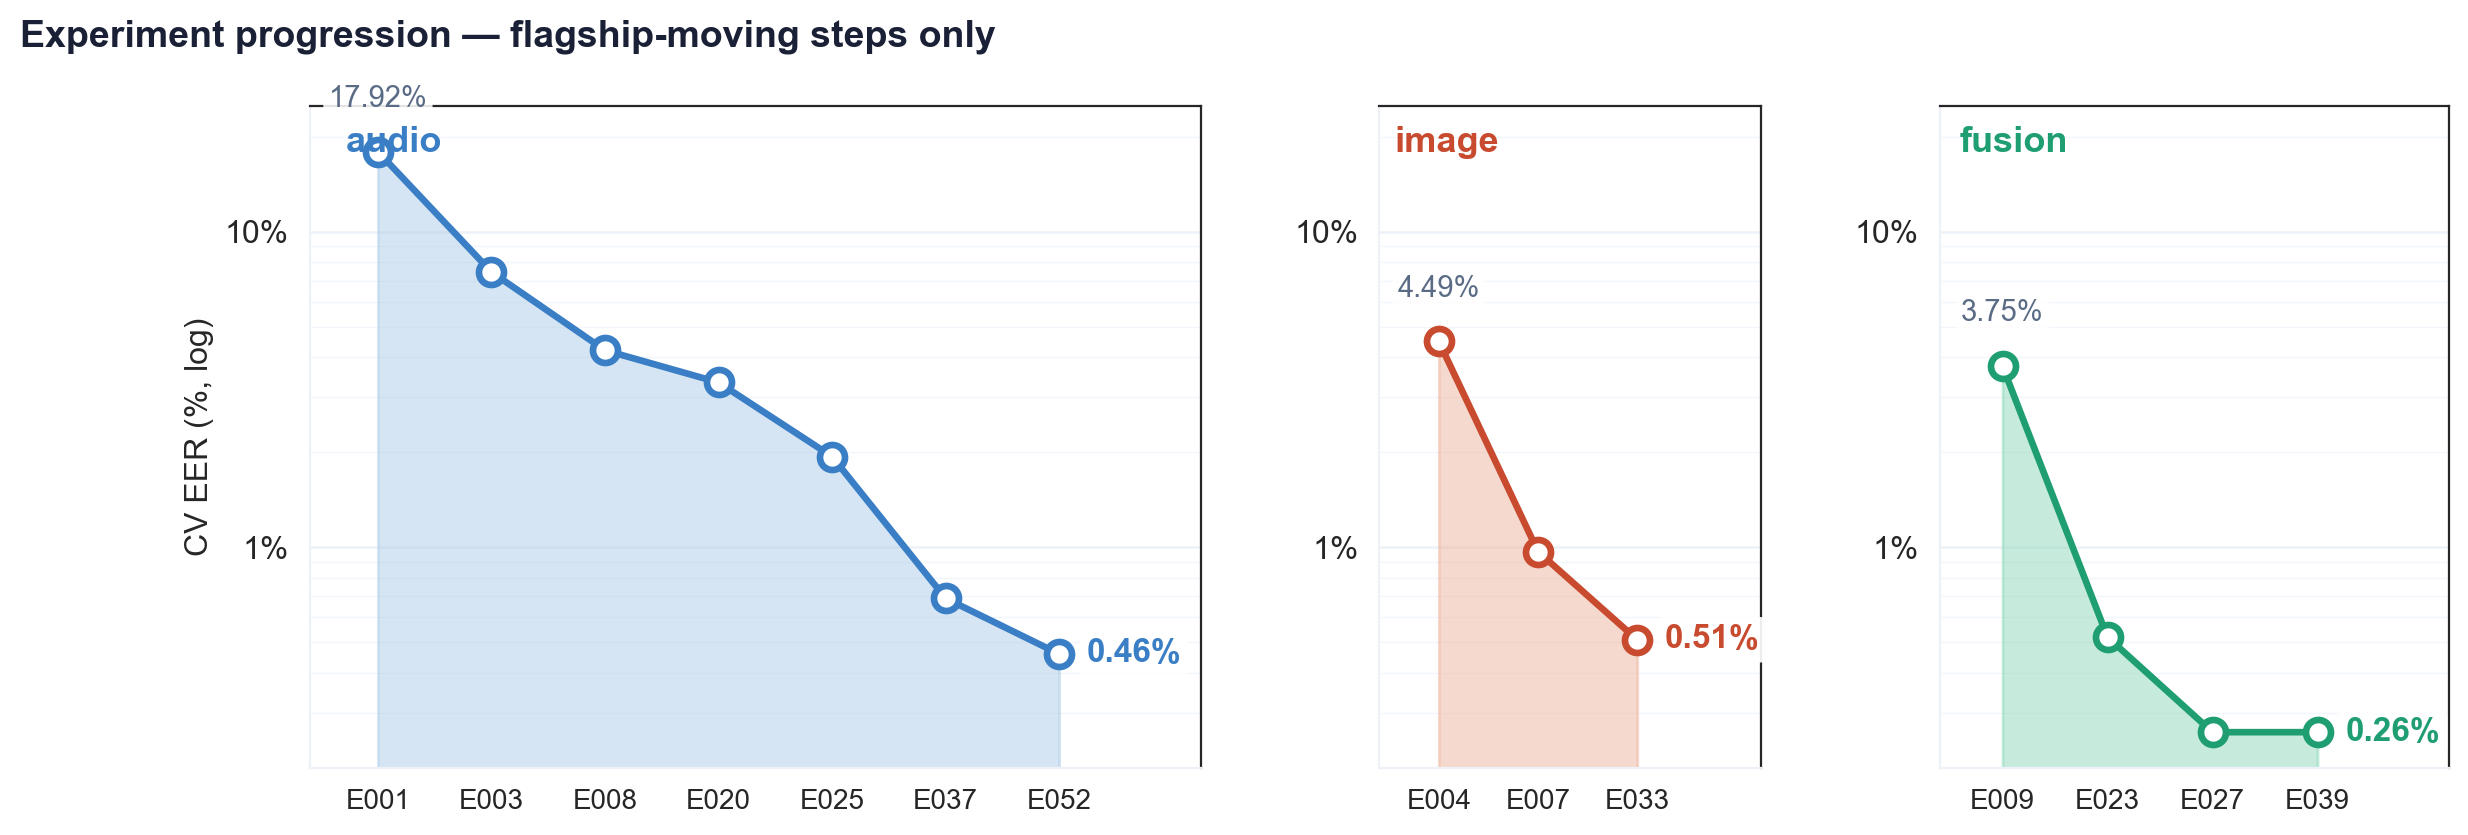

In [6]:
mile = pd.DataFrame([
    ("audio",  1, "E001", 17.92),
    ("audio",  2, "E003",  7.45),
    ("audio",  3, "E008",  4.21),
    ("audio",  4, "E020",  3.33),
    ("audio",  5, "E025",  1.94),
    ("audio",  6, "E037",  0.69),
    ("audio",  7, "E052",  0.46),
    ("image",  1, "E004",  4.49),
    ("image",  2, "E007",  0.97),
    ("image",  3, "E033",  0.51),
    ("fusion", 1, "E009",  3.75),
    ("fusion", 2, "E023",  0.52),
    ("fusion", 3, "E027",  0.26),
    ("fusion", 4, "E039",  0.26),
], columns=["stream", "step", "exp", "EER"])

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.3),
                         gridspec_kw=dict(width_ratios=[7, 3, 4], wspace=0.30))

for ax, stream in zip(axes, ["audio", "image", "fusion"]):
    sub = mile[mile["stream"] == stream].reset_index(drop=True)
    xs  = sub["step"].to_numpy(float)
    ys  = sub["EER"].to_numpy(float)
    col = STREAM[stream]; lt = STREAM_LT[stream]

    ax.fill_between(xs, ys, 0.18, color=lt, alpha=0.50, zorder=1)
    ax.plot(xs, ys, "o-", color=col, lw=2.4, ms=9,
            markerfacecolor="white", markeredgewidth=2.4, zorder=3,
            solid_capstyle="round")

    ax.set_yscale("log")
    ax.set_ylim(0.20, 25)
    ax.set_xlim(xs[0] - 0.6, xs[-1] + 1.25)
    ax.set_xticks(xs)
    ax.set_xticklabels(sub["exp"], fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
    ax.yaxis.grid(True, which="major", color=P["grid"], lw=0.9, zorder=0)
    ax.yaxis.grid(True, which="minor", color=P["grid"], lw=0.5, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["bottom"].set_color(P["grid"])
    ax.spines["left"].set_color(P["grid"])
    ax.tick_params(left=False)
    ax.set_ylabel("CV EER (%, log)" if stream == "audio" else "")

    # First-point label (above)
    ax.annotate(f"{ys[0]:.2f}%", xy=(xs[0], ys[0]),
                xytext=(0, 14), textcoords="offset points",
                ha="center", va="bottom", fontsize=10.5, color=P["sub"],
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.88))

    # Last-point label (right of marker, white bbox so fill doesn't bleed)
    ax.annotate(f"{ys[-1]:.2f}%", xy=(xs[-1], ys[-1]),
                xytext=(10, 0), textcoords="offset points",
                ha="left", va="center", fontsize=12, color=col, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.92))

    # Stream label inside
    ax.text(0.04, 0.97, stream, transform=ax.transAxes,
            ha="left", va="top", color=col, fontweight="semibold", fontsize=13)

fig.suptitle("Experiment progression — flagship-moving steps only",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig4_progression")
plt.show()

## Figure 5 — Stress-test robustness (E051)

  saved fig5_stress_robustness


/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_16330/1169482934.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


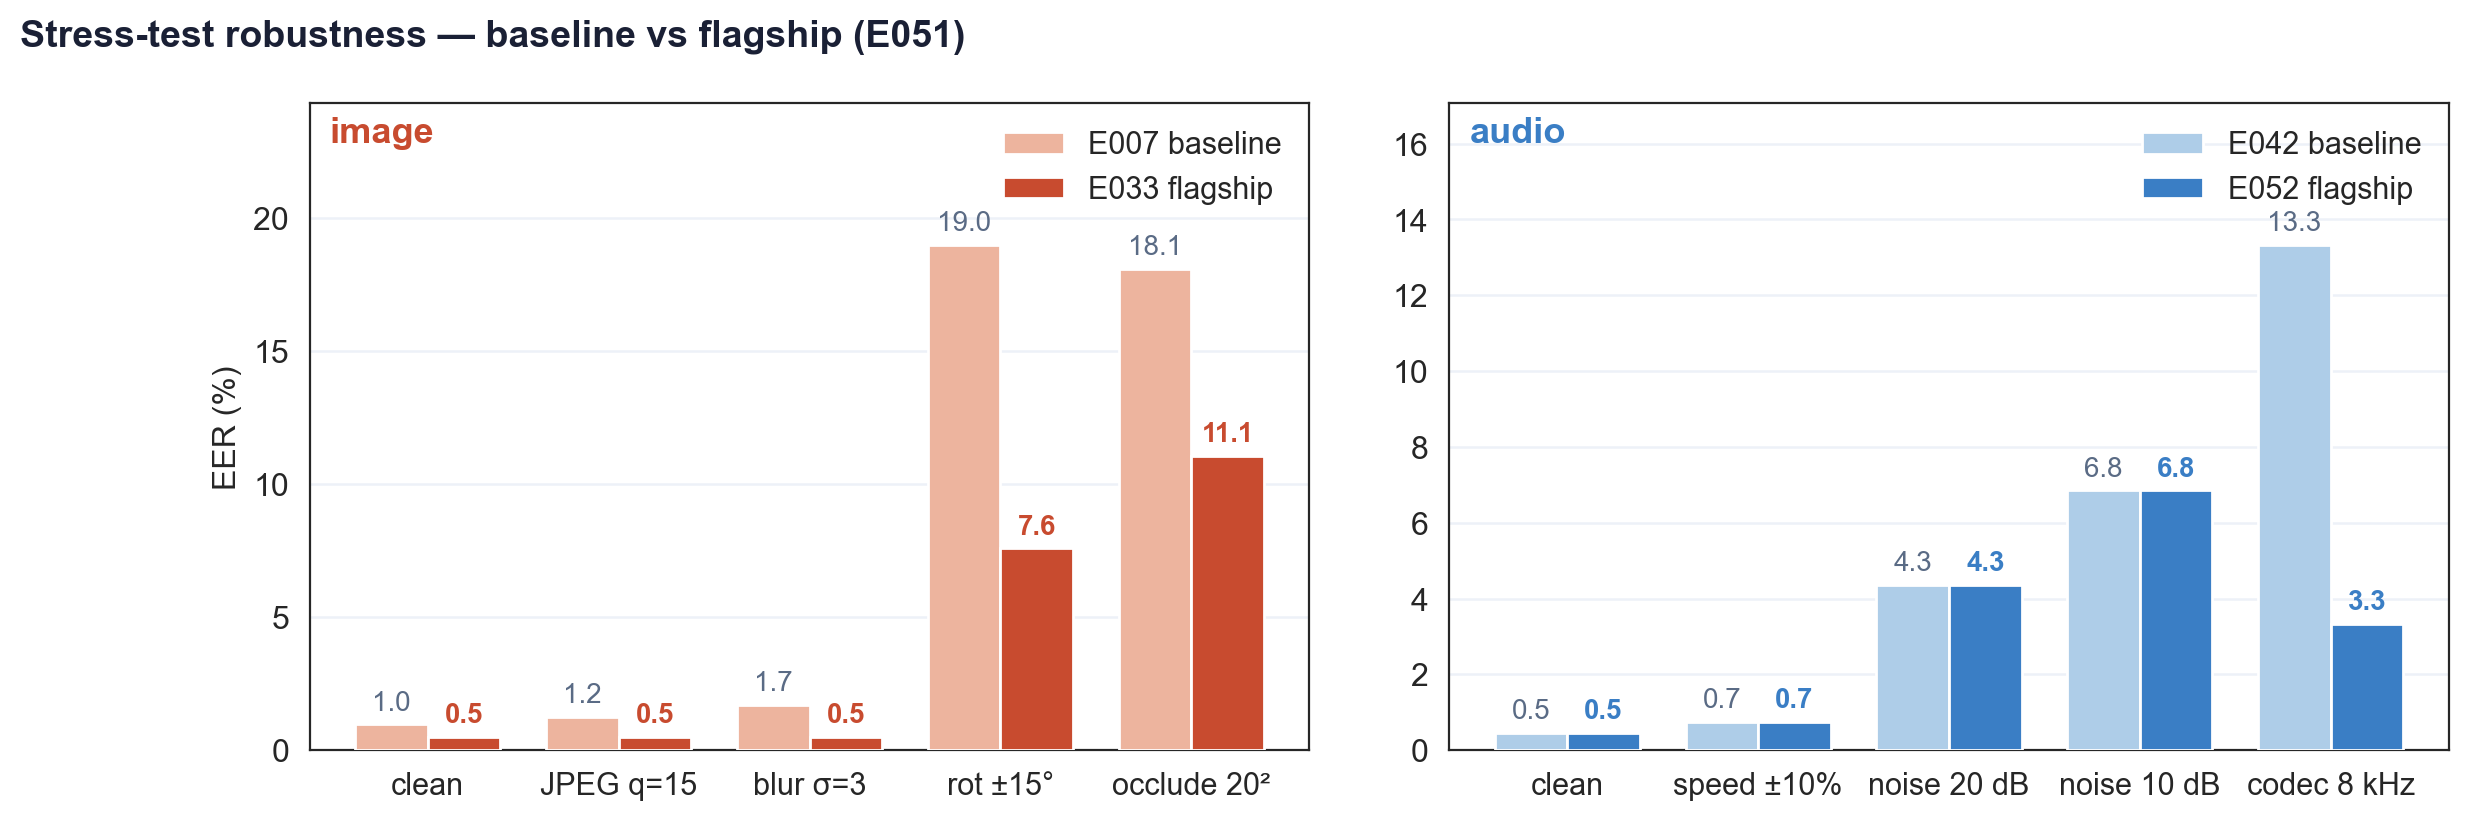

In [7]:
stress = pd.DataFrame([
    ("image", "clean",       "base",  0.97), ("image", "clean",       "flag",  0.51),
    ("image", "JPEG q=15",   "base",  1.25), ("image", "JPEG q=15",   "flag",  0.51),
    ("image", "blur σ=3",    "base",  1.71), ("image", "blur σ=3",    "flag",  0.51),
    ("image", "rot ±15°",    "base", 19.00), ("image", "rot ±15°",    "flag",  7.59),
    ("image", "occlude 20²", "base", 18.10), ("image", "occlude 20²", "flag", 11.06),
    ("audio", "clean",       "base",  0.46), ("audio", "clean",       "flag",  0.46),
    ("audio", "speed ±10%",  "base",  0.74), ("audio", "speed ±10%",  "flag",  0.74),
    ("audio", "noise 20 dB", "base",  4.35), ("audio", "noise 20 dB", "flag",  4.35),
    ("audio", "noise 10 dB", "base",  6.85), ("audio", "noise 10 dB", "flag",  6.85),
    ("audio", "codec 8 kHz", "base", 13.33), ("audio", "codec 8 kHz", "flag",  3.33),
], columns=["mod", "cond", "which", "EER"])

exp_map = {"image": ("E007", "E033"), "audio": ("E042", "E052")}
fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.2),
                         gridspec_kw=dict(wspace=0.14))

for ax, mod in zip(axes, ["image", "audio"]):
    sub   = stress[stress["mod"] == mod]
    conds = sub["cond"].unique()
    base  = sub[sub["which"] == "base"]["EER"].to_numpy()
    flag  = sub[sub["which"] == "flag"]["EER"].to_numpy()
    x = np.arange(len(conds)); w = 0.38
    lt, sat = STREAM_LT[mod], STREAM[mod]
    eb, ef  = exp_map[mod]

    ax.bar(x - w/2, base, w, color=lt,  zorder=3, label=f"{eb} baseline")
    ax.bar(x + w/2, flag, w, color=sat, zorder=3, label=f"{ef} flagship")

    ymax = float(sub["EER"].max()) * 1.28
    ax.set_ylim(0, ymax)
    ygrid(ax)
    ax.set_xticks(x); ax.set_xticklabels(conds, fontsize=11)
    ax.set_ylabel("EER (%)" if mod == "image" else "")

    pad = ymax * 0.013
    for xi, (b, f) in enumerate(zip(base, flag)):
        ax.text(xi - w/2, b + pad, f"{b:.1f}", ha="center", va="bottom",
                fontsize=10, color=P["sub"])
        ax.text(xi + w/2, f + pad, f"{f:.1f}", ha="center", va="bottom",
                fontsize=10, color=sat, fontweight="bold")

    ax.legend(loc="upper right", fontsize=11)
    ax.text(0.02, 0.98, mod, transform=ax.transAxes,
            ha="left", va="top", color=sat, fontweight="semibold", fontsize=13)

fig.suptitle("Stress-test robustness — baseline vs flagship (E051)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig5_stress_robustness")
plt.show()

## Load OOF scores (Figs 6 & 7)

In [8]:
with open(CACHE / "oof_scores.pkl", "rb") as fh:
    scores = pickle.load(fh)
print("keys:", list(scores.keys()))
print("weights:", scores.get("weights"))

keys: ['mfcc', 'lpcc', 'image', 'fusion', 'y', 'weights']
weights: (np.float64(0.0), np.float64(0.46), np.float64(0.54))


## Figure 6 — DET curves

  saved fig6_det_curve


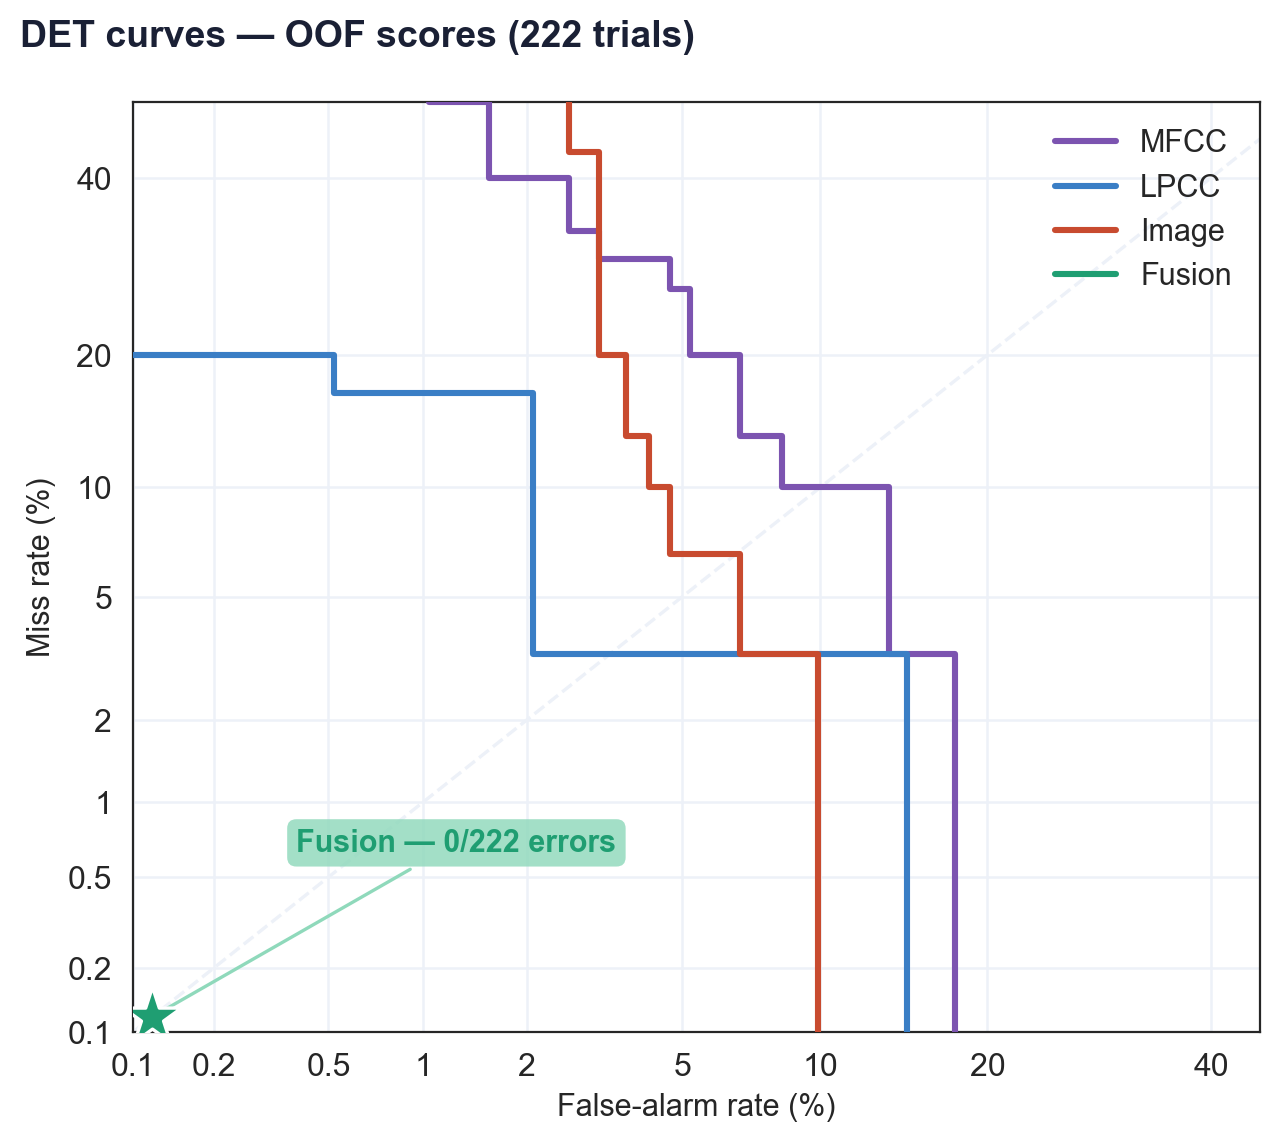

In [9]:
def probit(p):
    return ndtri(np.clip(p, 1e-4, 1 - 1e-4))

def det_curve(score, y):
    fpr, tpr, _ = roc_curve(y, score)
    return probit(fpr), probit(1 - tpr)

def det_axes(ax):
    ticks = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4]
    labs  = ["0.1", "0.2", "0.5", "1", "2", "5", "10", "20", "40"]
    pv    = [probit(t) for t in ticks]
    ax.set_xticks(pv); ax.set_xticklabels(labs)
    ax.set_yticks(pv); ax.set_yticklabels(labs)
    ax.set_xlim(probit(0.001), probit(0.45))
    ax.set_ylim(probit(0.001), probit(0.50))
    d = np.linspace(probit(0.001), probit(0.5), 200)
    ax.plot(d, d, "--", color=P["grid"], lw=1.2, zorder=0)
    xygrid(ax)

y_oof = scores["y"]
fig, ax = plt.subplots(figsize=(6.5, 5.8))
det_axes(ax)

for label, key, col in [
        ("MFCC",  "mfcc",  P["mfcc"]),
        ("LPCC",  "lpcc",  P["audio"]),
        ("Image", "image", P["image"]),
]:
    px, py = det_curve(scores[key], y_oof)
    ax.plot(px, py, color=col, lw=2.2, label=label, zorder=3)

# Fusion: full DET curve + EER star
fpr_f, tpr_f, thr_f = roc_curve(y_oof, scores["fusion"])
fnr_f = 1 - tpr_f
ax.plot(probit(np.clip(fpr_f, 1e-4, 1-1e-4)),
        probit(np.clip(fnr_f, 1e-4, 1-1e-4)),
        color=P["fusion"], lw=2.2, label="Fusion", zorder=3)
# Fine-grid EER so we don't land on step-function vertex at 0
fprs_g  = np.linspace(1e-4, 0.5, 50000)
fnrs_g  = np.interp(fprs_g, fpr_f, fnr_f)
ei      = np.argmin(np.abs(fprs_g - fnrs_g))
eer_fpr = float(max(fprs_g[ei], 1e-4))
eer_fnr = float(max(fnrs_g[ei], 1e-4))
xlim    = ax.get_xlim(); ylim = ax.get_ylim()
fx      = float(np.clip(probit(eer_fpr), xlim[0] + 0.05, xlim[1] - 0.05))
fy      = float(np.clip(probit(eer_fnr), ylim[0] + 0.05, ylim[1] - 0.05))
ax.scatter([fx], [fy], marker="*", s=480, color=P["fusion"],
           edgecolors="white", linewidths=1.2, zorder=6)
ax.annotate("Fusion — 0/222 errors",
            xy=(fx, fy), xytext=(fx + 0.38, fy + 0.55),
            fontsize=11, color=P["fusion"], fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=P["fusion_lt"], lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", fc=P["fusion_lt"],
                      ec="none", alpha=0.82))

ax.set_xlabel("False-alarm rate (%)", fontsize=11)
ax.set_ylabel("Miss rate (%)", fontsize=11)
ax.legend(loc="upper right", fontsize=11)

fig.suptitle("DET curves — OOF scores (222 trials)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig6_det_curve")
plt.show()

## Figure 7 — Fused OOF score distribution

  saved fig7_score_histogram


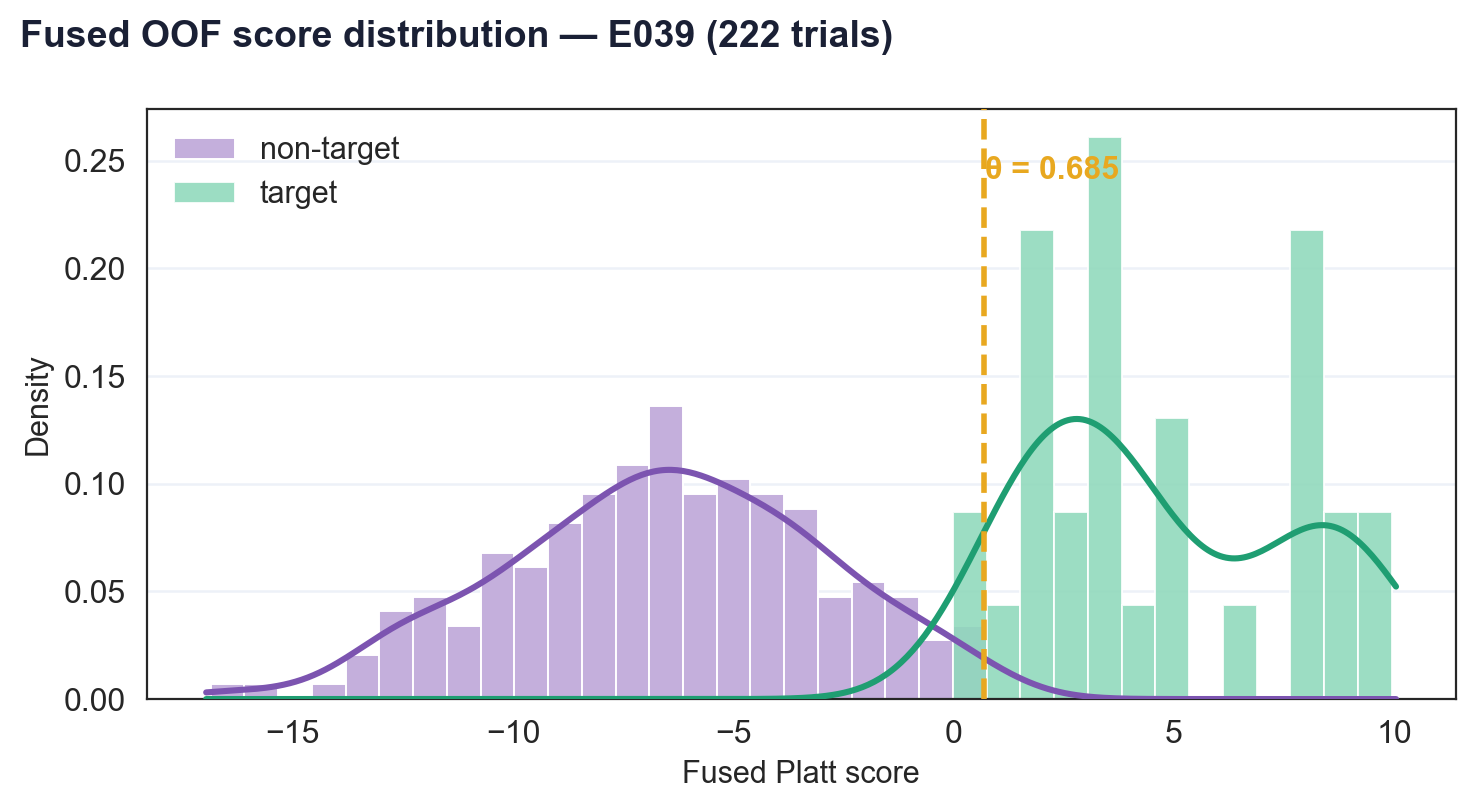

In [10]:
fused = scores["fusion"]
y_oof = scores["y"]
tgt   = fused[y_oof == 1]
non   = fused[y_oof == 0]

fig, ax = plt.subplots(figsize=(7.5, 4.1))

bins = np.linspace(fused.min() - 0.05, fused.max() + 0.05, 36)
ax.hist(non, bins=bins, color=P["mfcc_lt"],  edgecolor="white", lw=0.7,
        density=True, zorder=2, label="non-target")
ax.hist(tgt, bins=bins, color=P["fusion_lt"], edgecolor="white", lw=0.7,
        density=True, alpha=0.88, zorder=2, label="target")

xs = np.linspace(fused.min() - 0.15, fused.max() + 0.15, 400)
ax.plot(xs, stats.gaussian_kde(non)(xs), color=P["mfcc"],   lw=2.2, zorder=4)
ax.plot(xs, stats.gaussian_kde(tgt)(xs), color=P["fusion"], lw=2.2, zorder=4)

# Bayes threshold (EER point)
fpr_f, tpr_f, thr_f = roc_curve(y_oof, fused)
fnr_f = 1 - tpr_f
idx   = np.argmin(np.abs(fpr_f - fnr_f))
thr   = thr_f[min(idx, len(thr_f) - 1)]

ax.axvline(thr, color=P["amber"], lw=2.0, ls="--", zorder=5)
ylim_top = ax.get_ylim()[1]
ax.text(thr + 0.025, ylim_top * 0.92, f"θ = {thr:.3f}",
        color=P["amber"], fontsize=11.5, fontweight="bold", va="top")

ax.set_xlabel("Fused Platt score", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.legend(loc="upper left", fontsize=11)
ygrid(ax)

fig.suptitle("Fused OOF score distribution — E039 (222 trials)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
save(fig, "fig7_score_histogram")
plt.show()

### Done — 7 figures saved to `docs/figures/`.